In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import missingno as msno
import joblib

# Establish Country & Pollutant

In [2]:
load_dotenv()

True

In [3]:
POLLUTANT = "PM10"

In [4]:
COUNTRY_CODE = os.getenv("COUNTRY_CODE")  
RESULTS_SAVE_FOLDER = os.getenv("RESULTS_SAVE_FOLDER")

In [5]:
RUN_ID = f"{COUNTRY_CODE}_{POLLUTANT}"

output_dir = Path(RESULTS_SAVE_FOLDER) / f"Results_{RUN_ID}"
output_dir.mkdir(parents=True, exist_ok=True)

# Load Data

In [7]:
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

In [8]:
table_name = f"air_quality_{COUNTRY_CODE}"

In [9]:
query = f"""
SELECT * FROM {table_name} 
WHERE "Pollutant" = 5;
"""

df= pd.read_sql_query(query, engine)

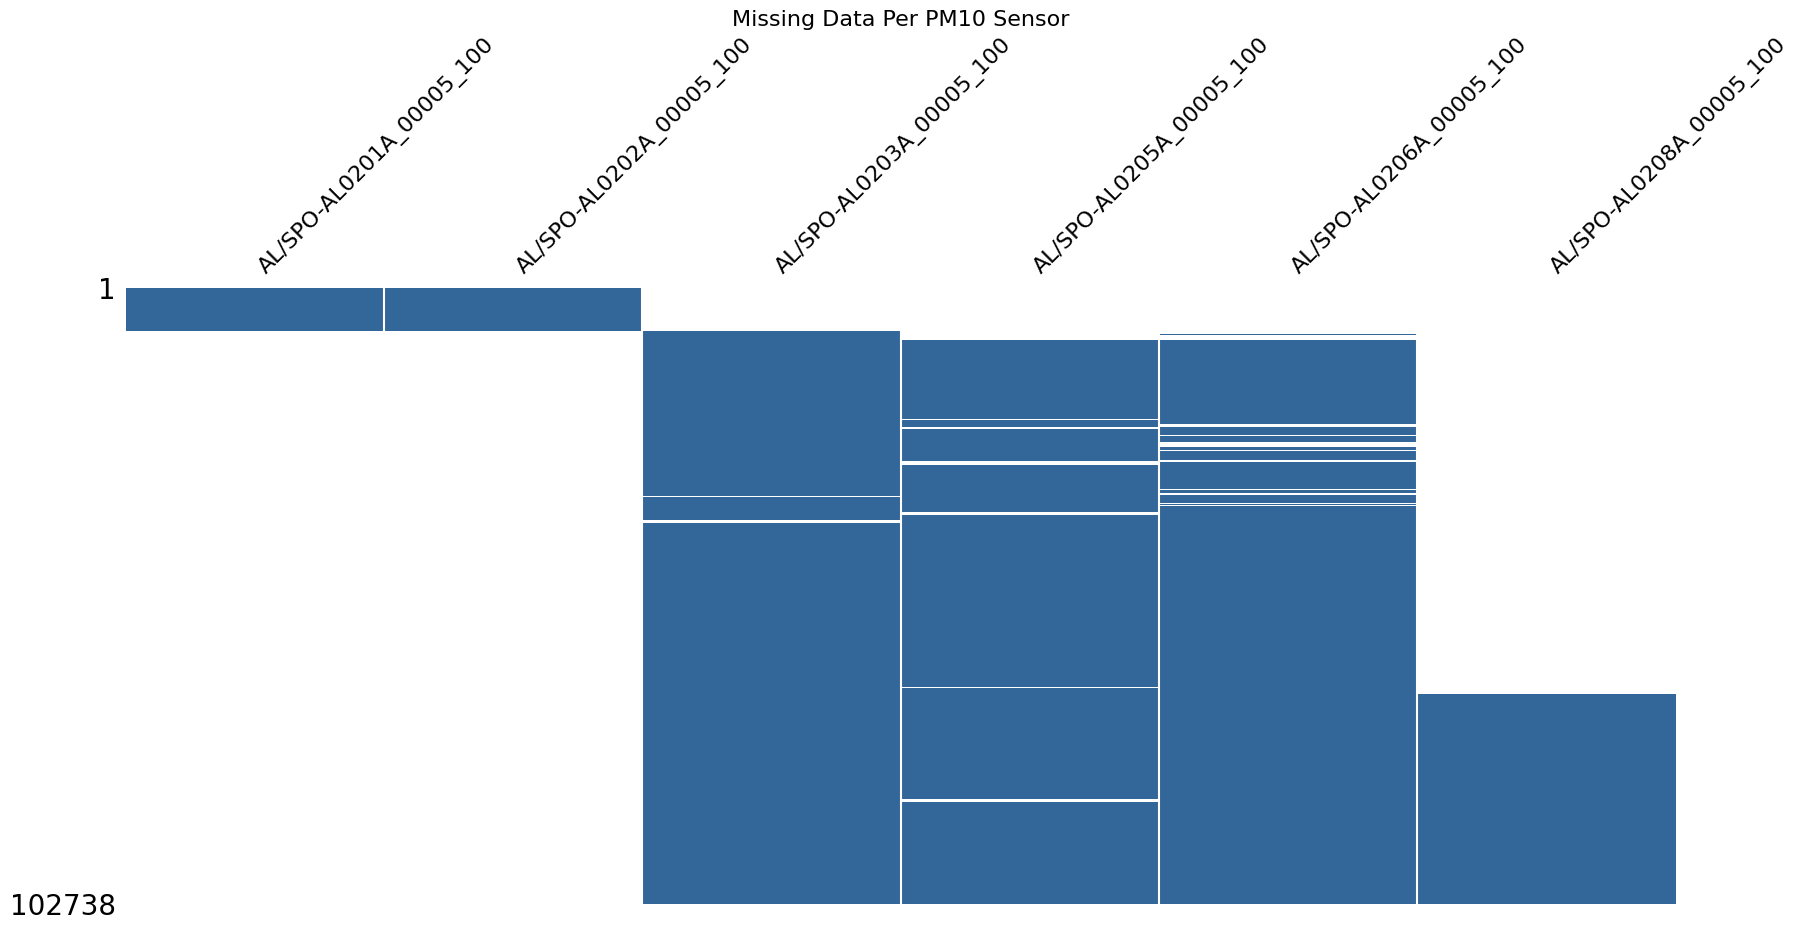

Longest continuous NaN streaks per PM10 Station:
Samplingpoint
AL/SPO-AL0201A_00005_100    0
AL/SPO-AL0202A_00005_100    0
AL/SPO-AL0203A_00005_100    0
AL/SPO-AL0205A_00005_100    0
AL/SPO-AL0206A_00005_100    0
AL/SPO-AL0208A_00005_100    0
Name: Value, dtype: int64


In [10]:
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

df_pivot = df.pivot_table(index='Start', columns='Samplingpoint', values='Value') # pivot the data to get a matrix of sampling points vs time, with the values being the pollutant measurements.

# Visualize the missing data gaps per sensor with msno matrix to show presence and absence of data
msno.matrix(df_pivot, figsize=(20, 8), color=(0.2, 0.4, 0.6), sparkline=False)
plt.title(f"Missing Data Per {POLLUTANT} Sensor", fontsize=16)
plt.savefig(output_dir / f"{RUN_ID}_msno_matrix.png", bbox_inches='tight')
plt.show()
plt.close()
# longest streak of missing data
def max_consecutive_nans(series):
    is_na = series.isna()
    # Cumulatively (cumsum) sum the non-NaNs to create unique group IDs for consecutive NaNs
    return is_na.groupby((~is_na).cumsum()).sum().max()

longest_nan_streaks = df.groupby('Samplingpoint')['Value'].apply(max_consecutive_nans) 
longest_nan_streaks = longest_nan_streaks.sort_values(ascending=False)

print(f"Longest continuous NaN streaks per {POLLUTANT} Station:")
print(longest_nan_streaks.head(10))

In [12]:
df['Start'] = pd.to_datetime(df['Start'])

In [13]:
print(f"Rows in dataset: {len(df)}")
print(f"NaN rows in dataset: {df['Value'].isna().sum()}")
print(f"Non-NaN rows in dataset: {df['Value'].notna().sum()}")
df.head()

Rows in dataset: 326285
NaN rows in dataset: 0
Non-NaN rows in dataset: 326285


,Samplingpoint,Pollutant,Start,End,Value,Unit,AggType,Validity,Verification,ResultTime,DataCapture
0,AL/SPO-AL0201A_00005_100,5,2013-01-01 00:00:00,2013-01-01 01:00:00,0.00,ug.m-3,hour,-1,1,2014-12-01 20:21:25,None
1,AL/SPO-AL0201A_00005_100,5,2013-01-01 01:00:00,2013-01-01 02:00:00,212.02,ug.m-3,hour,1,1,2014-12-01 20:21:25,None
2,AL/SPO-AL0201A_00005_100,5,2013-01-01 02:00:00,2013-01-01 03:00:00,165.64,ug.m-3,hour,1,1,2014-12-01 20:21:25,None
3,AL/SPO-AL0201A_00005_100,5,2013-01-01 03:00:00,2013-01-01 04:00:00,79.48,ug.m-3,hour,1,1,2014-12-01 20:21:25,None
4,AL/SPO-AL0201A_00005_100,5,2013-01-01 04:00:00,2013-01-01 05:00:00,62.51,ug.m-3,hour,1,1,2014-12-01 20:21:25,None


# Clean Data & Fill gaps when it makes sense to do so

In [15]:
df.loc[(df['Value'] < 0) | (df['Validity'] == -1), 'Value'] = np.nan # Set all invalid and impossible values to NaN

print(f"Total NaN readings after removing data collection errors: {df['Value'].isna().sum()}")

Total NaN readings after removing data collection errors: 173552


In [17]:
df_unified = df.copy() # due to using samplingpoint (previosuly split it up into staionid and sample) this si to work with my code.

# Interpolation to Fill in gaps when possible

In [18]:
# Daily Time weighted linear interpolation, 2 missing days max
def apply_daily_interpolation(station_group):
    
    # Enforce a continuous daily timeline, required to expose hidden missing days
    station_group = station_group.set_index('Start').resample('D').asfreq()
    
    station_group['Value'] = station_group['Value'].interpolate(method='time', limit=2) #  interpolate max 2 days
    
    return station_group[['Value']]

In [19]:
# Apply the interpolation per station
df_daily_Final = df_unified.groupby('Samplingpoint').apply(apply_daily_interpolation).reset_index()

print(f"Daily dataset rows after interpolation: {len(df_daily_Final)}")
print(f"Remaining persistent NaNs with gaps for than 2 days: {df_daily_Final['Value'].isna().sum()}")
df_daily_Final.head()

Daily dataset rows after interpolation: 14052
Remaining persistent NaNs with gaps for than 2 days: 7468


,Samplingpoint,Start,Value
0,AL/SPO-AL0201A_00005_100,2013-01-01,NaN
1,AL/SPO-AL0201A_00005_100,2013-01-02,21.94
2,AL/SPO-AL0201A_00005_100,2013-01-03,31.18
3,AL/SPO-AL0201A_00005_100,2013-01-04,16.66
4,AL/SPO-AL0201A_00005_100,2013-01-05,27.60


# Saving Cleaned Data

In [21]:
target_folder = os.getenv("BASE_DATA_PATH") # target folder saved in .env

# Dynamically naming country and polulutant for auto name and save
file_name = f"{COUNTRY_CODE}_{POLLUTANT}_Daily_Cleaned.parquet"
file_path = os.path.join(target_folder, file_name)

df_daily_Final.to_parquet(file_path, index=False) # save cleaned data as parquet

# Before, During & After Plotted

In [22]:
print("Before Interpolation (df_unified)")
print(f"Total NaNs: {df_unified['Value'].isna().sum()}")
print(df_unified['Value'].describe())

print("\nAfter Interpolaton (df_daily_Final)")
print(f"Total NaNs: {df_daily_Final['Value'].isna().sum()}")
print(df_daily_Final['Value'].describe())

Before Interpolation (df_unified)
Total NaNs: 173552
count    152733.000000
mean         23.788848
std          31.903748
min           0.000000
25%           7.980000
50%          16.466000
75%          28.714000
max         962.610000
Name: Value, dtype: float64

After Interpolaton (df_daily_Final)
Total NaNs: 7468
count    6584.000000
mean       21.431048
std        27.781080
min         0.000000
25%         6.925750
50%        15.446500
75%        26.340250
max       469.140000
Name: Value, dtype: float64


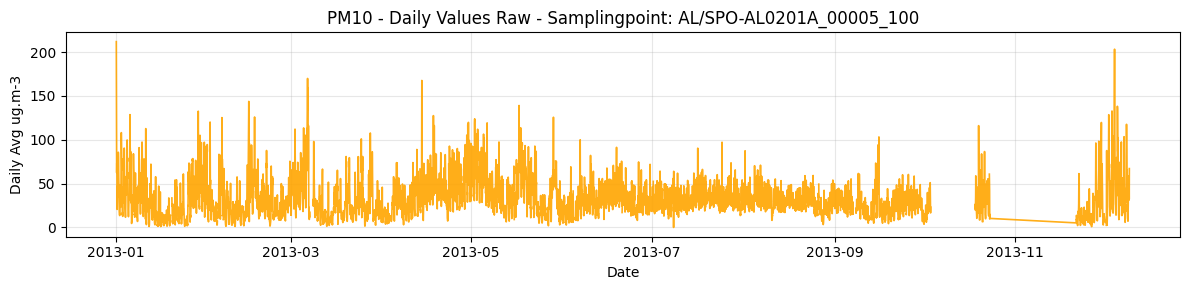

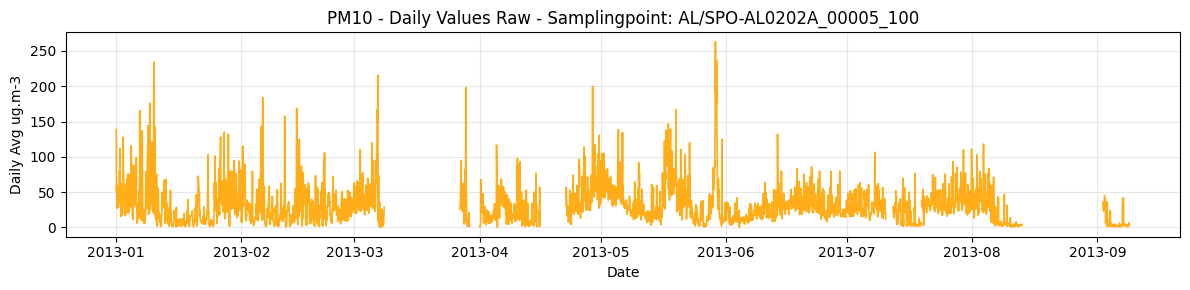

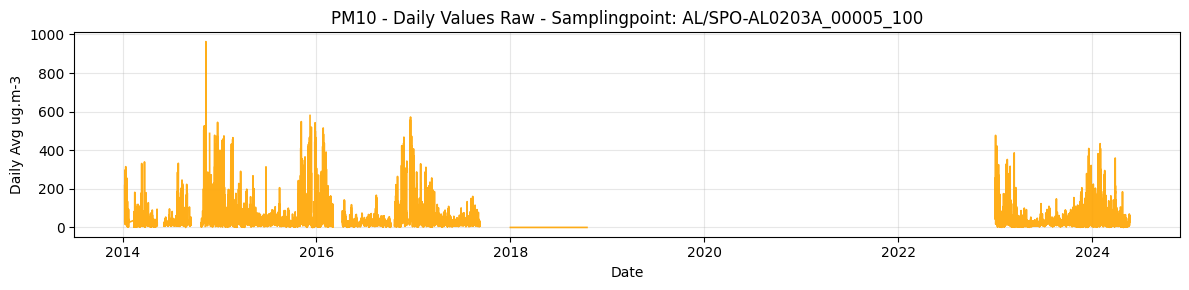

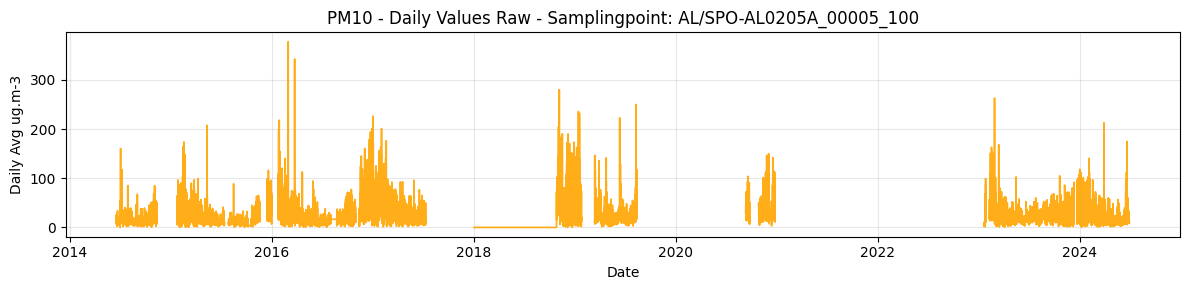

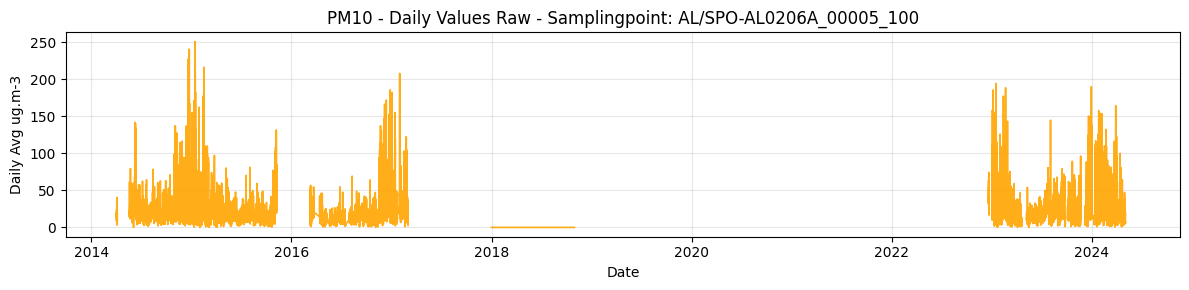

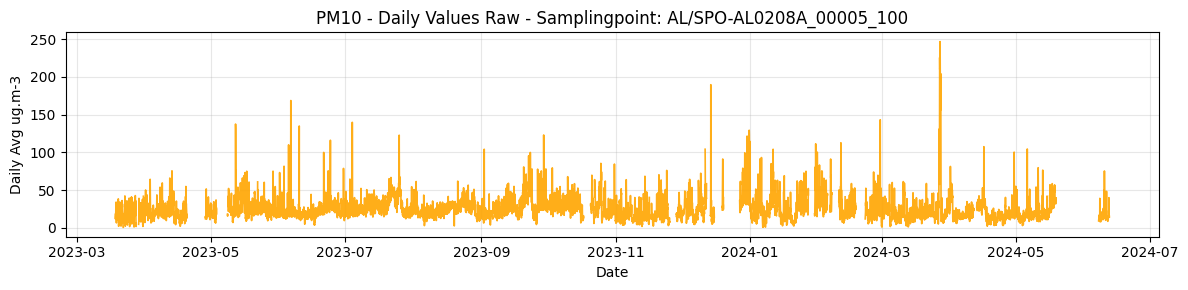

In [24]:
plot_dir = output_dir / "Daily_Raw_Plots"
plot_dir.mkdir(parents=True, exist_ok=True)

stations = df_unified['Samplingpoint'].unique()

for station in stations:
    station_data = df_unified[df_unified['Samplingpoint'] == station]
    
    plt.figure(figsize=(12, 3))
    plt.plot(station_data['Start'], station_data['Value'], color='orange', alpha=0.9, linewidth=1.2)
    plt.title(f'{POLLUTANT} - Daily Values Raw - Samplingpoint: {station}')
    plt.ylabel('Daily Avg ug.m-3')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_daily_raw.png"
    plt.savefig(plot_dir / file_name, dpi=150) # Save it to the new folder
    plt.tight_layout()
    plt.show()
    plt.close()

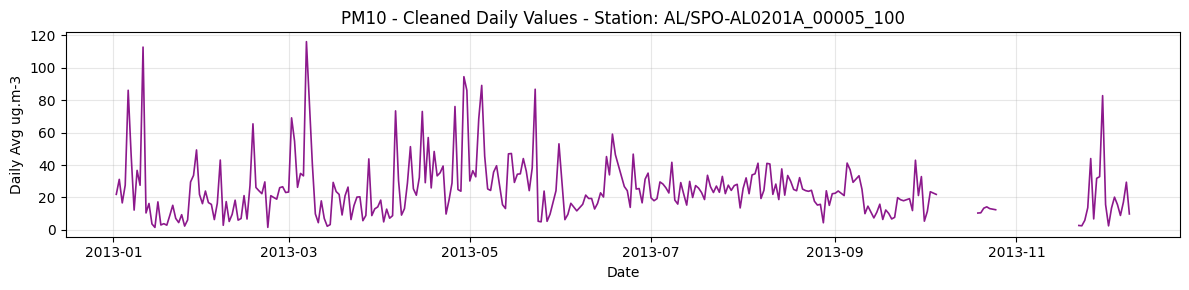

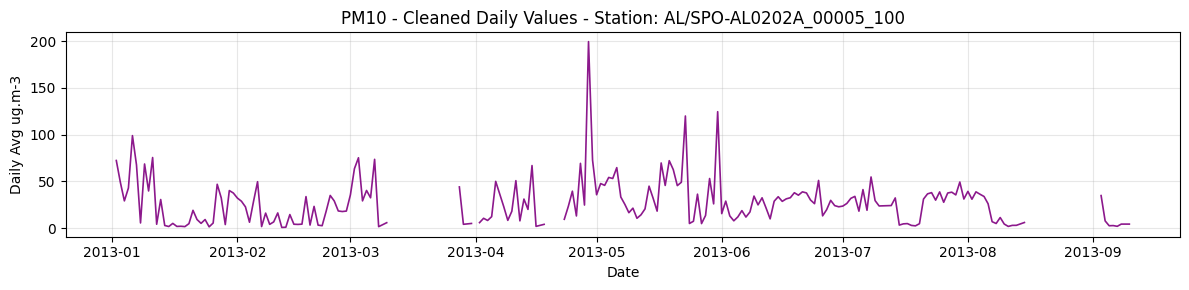

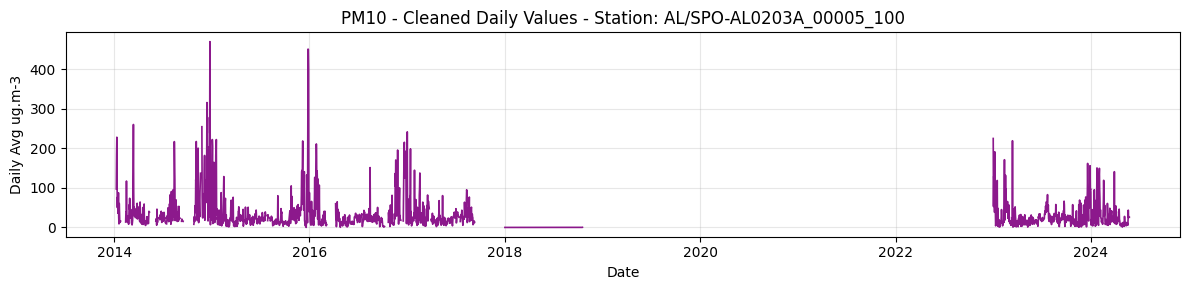

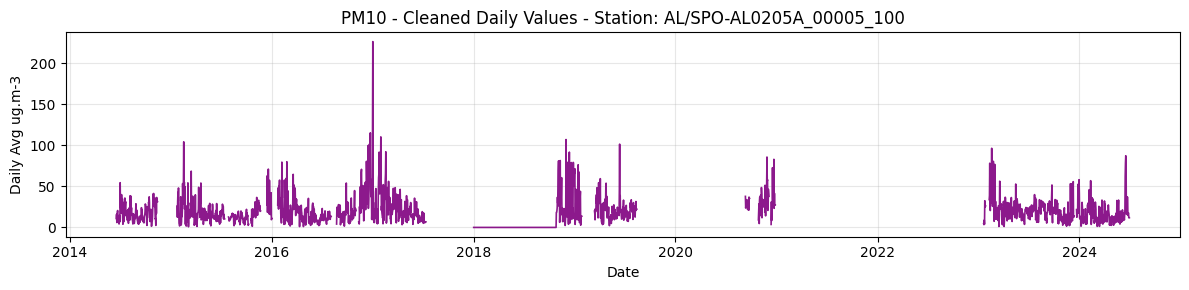

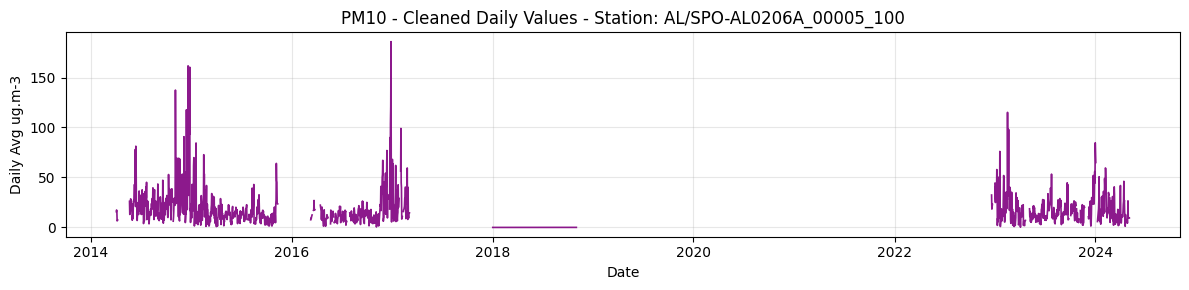

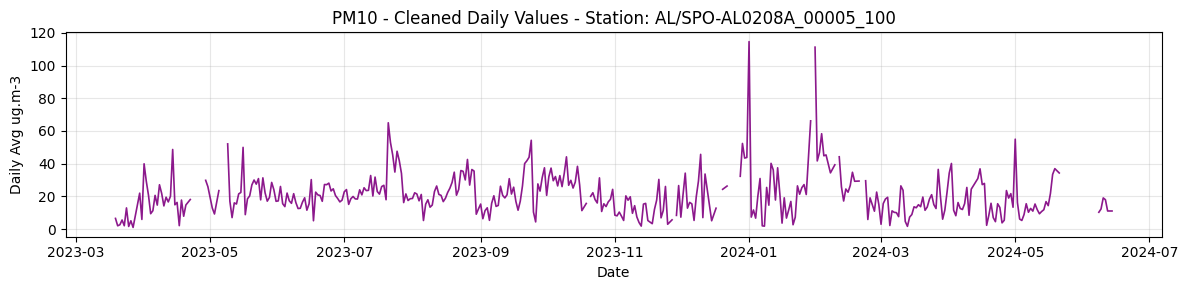

In [25]:
plot_dir = output_dir / "Cleaned_Daily_Plots"
plot_dir.mkdir(parents=True, exist_ok=True)

stations = df_daily_Final['Samplingpoint'].unique()

for station in stations:
    station_data = df_daily_Final[df_daily_Final['Samplingpoint'] == station]
    
    plt.figure(figsize=(12, 3))
    plt.plot(station_data['Start'], station_data['Value'], color='purple', alpha=0.9, linewidth=1.2)
    plt.title(f'{POLLUTANT} - Cleaned Daily Values - Station: {station}')
    plt.ylabel('Daily Avg ug.m-3')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_cleanData_Daily.png"
    plt.savefig(plot_dir / file_name, dpi=150) # Save it to the new folder
    plt.tight_layout()
    plt.show()
    plt.close()